# Experiment 9 - Generative Adversarial Network

In [2]:
!pip install wandb huggingface_hub -q

In [3]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

...

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chiragwalia0 (chiragwalia0-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "chiragwalia0/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 2
BATCH_SIZE    = 128
LATENT_DIM    = 10
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


### Dataset

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]

train: 60000  test: 10000


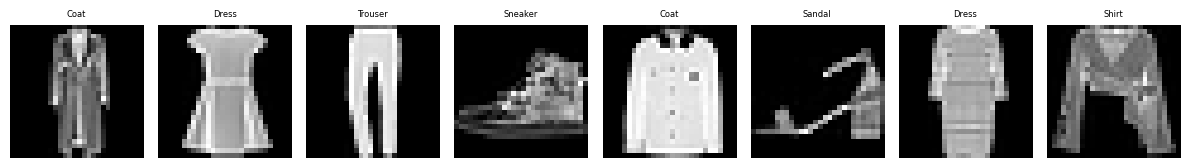

In [6]:
# normalize to [-1, 1] for GAN training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [7]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [8]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [9]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [10]:
def get_optimizer(model, name):
    if name == 'adam':
        # betas tuned for GAN stability
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [11]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [12]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2  # [-1,1] -> [0,1]
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [13]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

### Quick Test - run this first


starting: vanilla_bce_adam


  epoch 1/2  g_loss=0.9749  d_loss=0.5559
  epoch 2/2  g_loss=1.3968  d_loss=0.5626


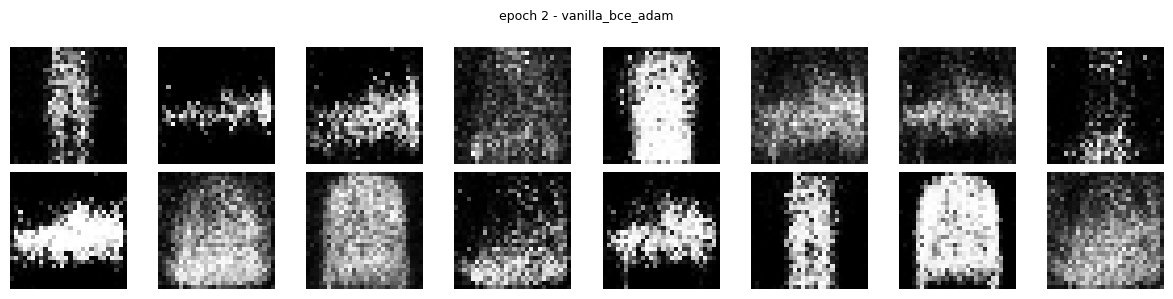

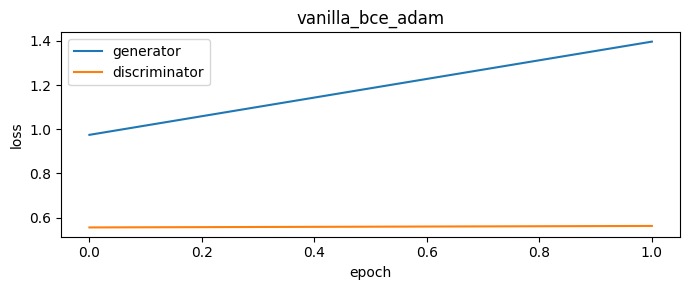

d_loss,▁█
epoch,▁█
g_loss,▁█
d_loss,0.56259
epoch,2
g_loss,1.39675



starting: dcgan_bce_adam


  epoch 1/2  g_loss=1.0420  d_loss=0.5856
  epoch 2/2  g_loss=0.9379  d_loss=0.6071


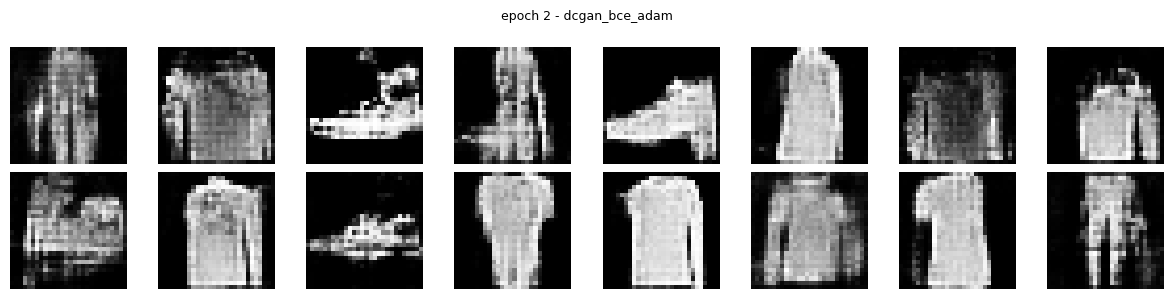

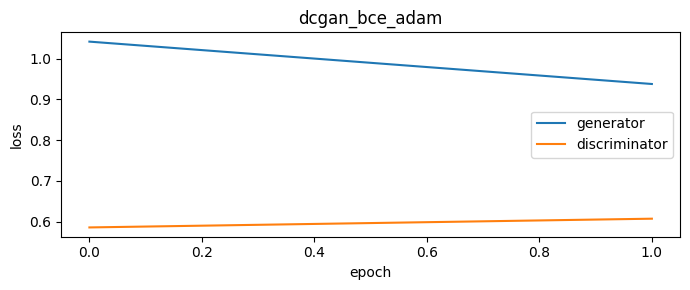

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,0.6071
epoch,2
g_loss,0.93792


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(10, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
     

In [14]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/2  g_loss=0.9925  d_loss=0.5564
  epoch 2/2  g_loss=1.3106  d_loss=0.5737


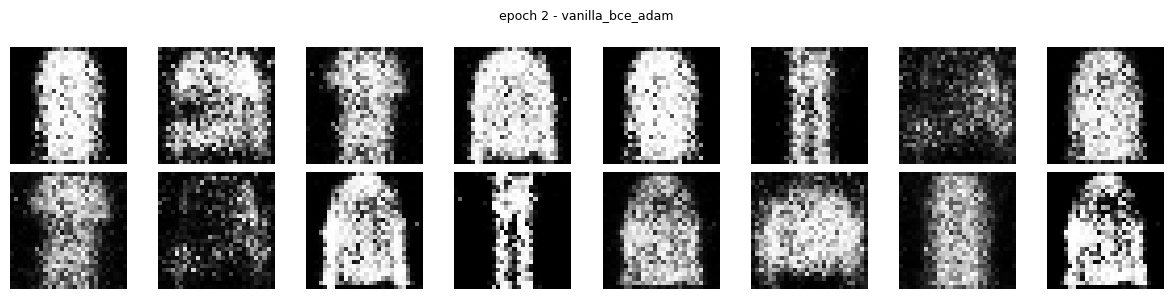

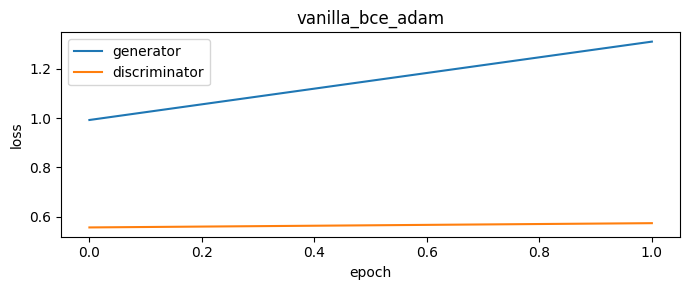

d_loss,▁█
epoch,▁█
g_loss,▁█
d_loss,0.57367
epoch,2
g_loss,1.31062



starting: vanilla_bce_sgd


  epoch 1/2  g_loss=0.7845  d_loss=0.3856
  epoch 2/2  g_loss=1.4606  d_loss=0.3279


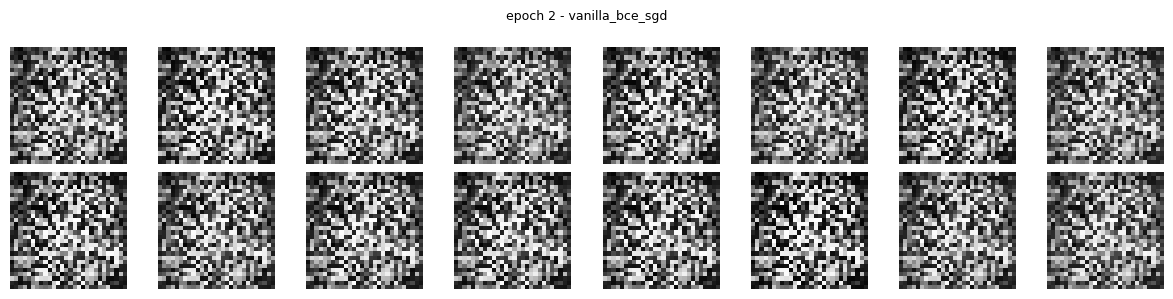

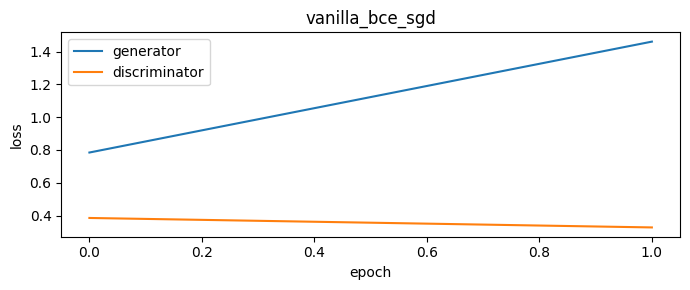

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.32789
epoch,2
g_loss,1.46059



starting: vanilla_bce_rmsprop


  epoch 1/2  g_loss=0.7888  d_loss=0.5084
  epoch 2/2  g_loss=1.0946  d_loss=0.4764


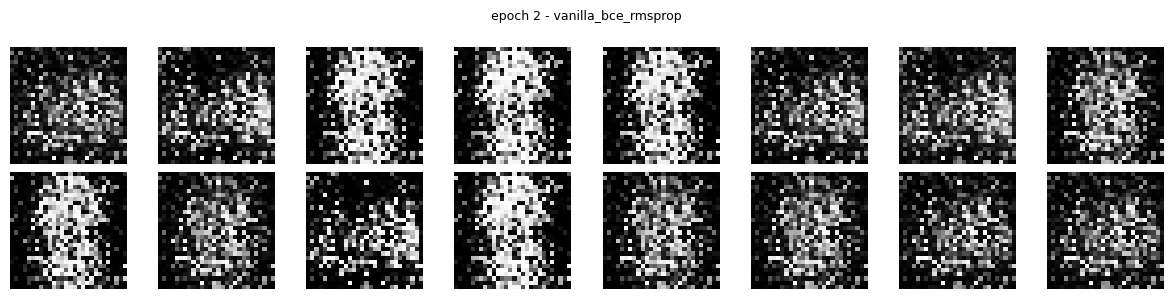

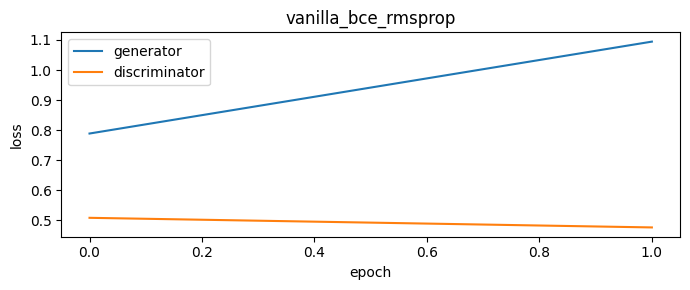

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.47639
epoch,2
g_loss,1.09456



starting: vanilla_lsgan_adam


  epoch 1/2  g_loss=0.9305  d_loss=0.0911
  epoch 2/2  g_loss=0.7077  d_loss=0.1500


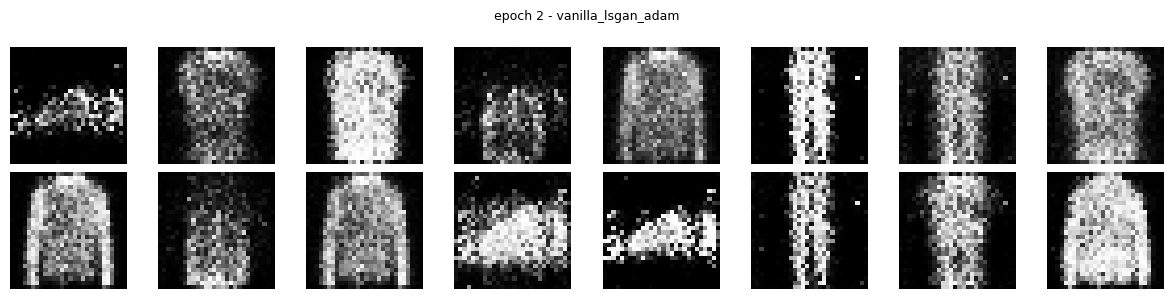

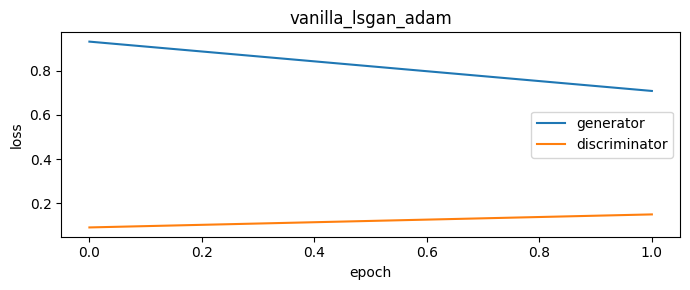

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,0.14996
epoch,2
g_loss,0.70768



starting: vanilla_lsgan_sgd


  epoch 1/2  g_loss=0.7189  d_loss=0.0417
  epoch 2/2  g_loss=1.0221  d_loss=0.0308


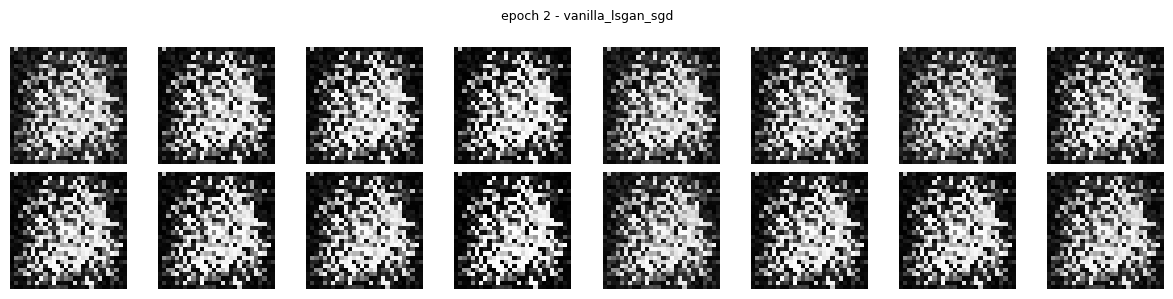

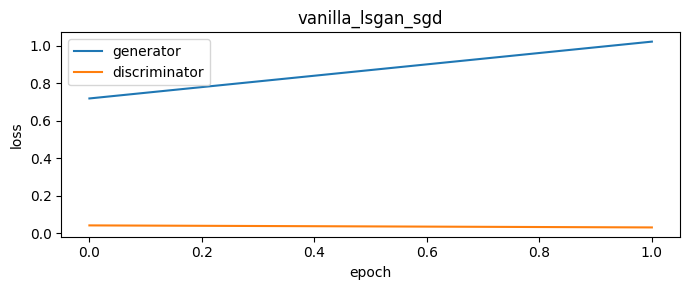

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.03083
epoch,2
g_loss,1.02213



starting: vanilla_lsgan_rmsprop


  epoch 1/2  g_loss=0.8652  d_loss=0.0704
  epoch 2/2  g_loss=0.9653  d_loss=0.0725


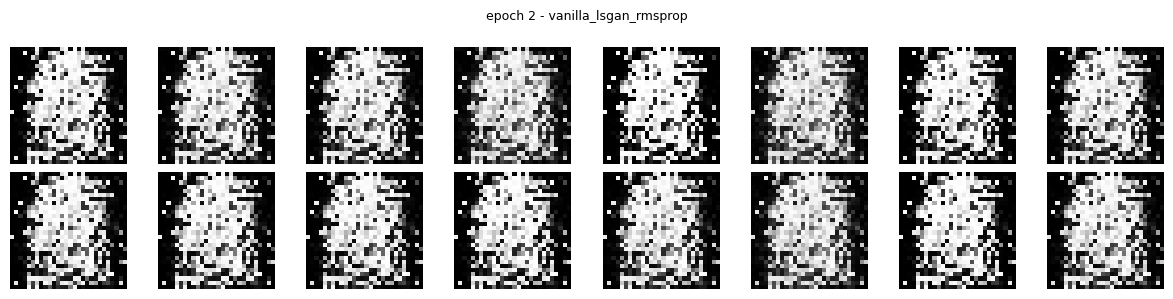

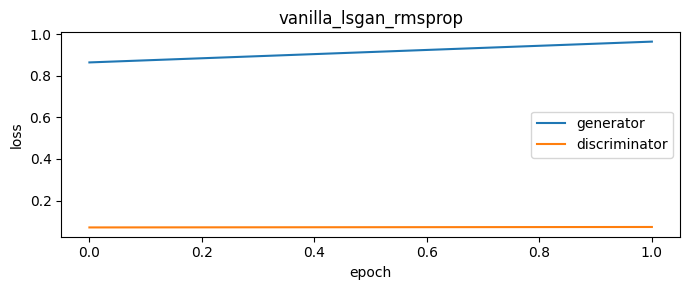

d_loss,▁█
epoch,▁█
g_loss,▁█
d_loss,0.07254
epoch,2
g_loss,0.96532



starting: vanilla_wgan_adam


  epoch 1/2  g_loss=-0.2088  d_loss=-0.2705
  epoch 2/2  g_loss=-0.2552  d_loss=-0.1748


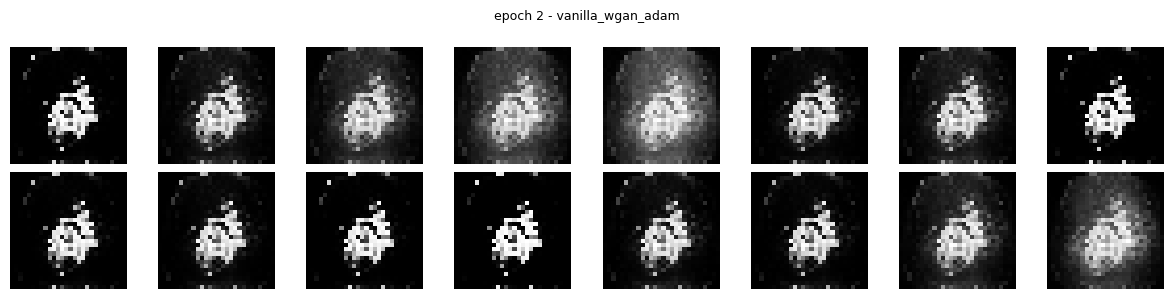

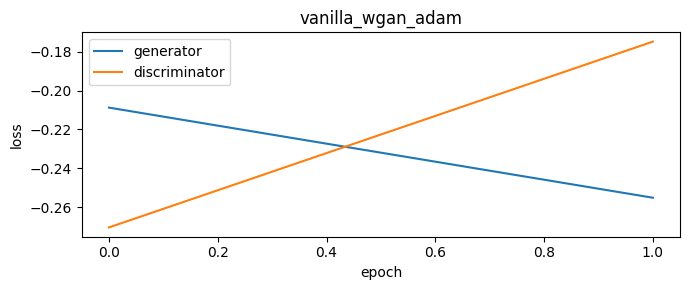

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,-0.17476
epoch,2
g_loss,-0.25518



starting: vanilla_wgan_sgd


  epoch 1/2  g_loss=-0.2731  d_loss=-1.6319
  epoch 2/2  g_loss=2.1906  d_loss=-0.5954


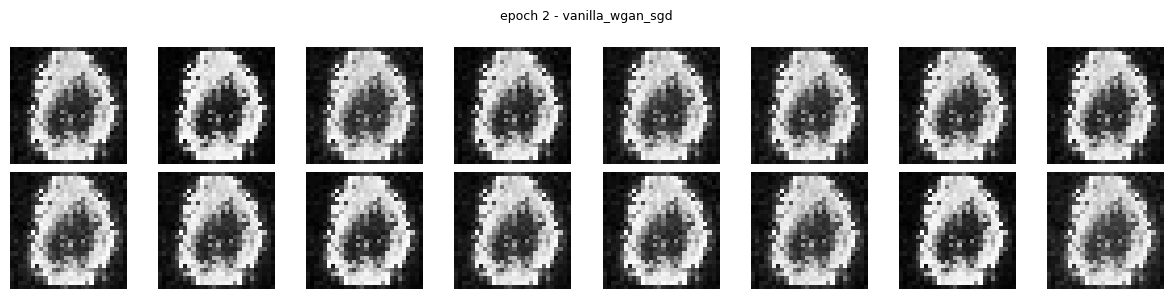

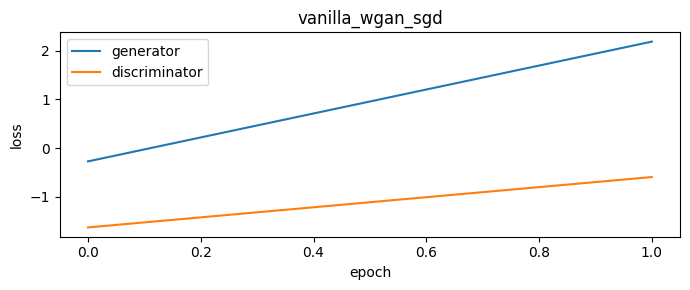

d_loss,▁█
epoch,▁█
g_loss,▁█
d_loss,-0.59536
epoch,2
g_loss,2.19064



starting: vanilla_wgan_rmsprop


  epoch 1/2  g_loss=-0.0954  d_loss=-0.1522
  epoch 2/2  g_loss=-0.4469  d_loss=-0.3246


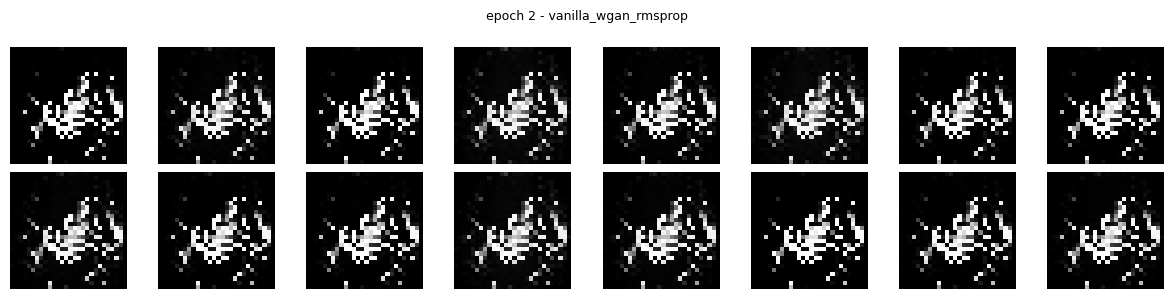

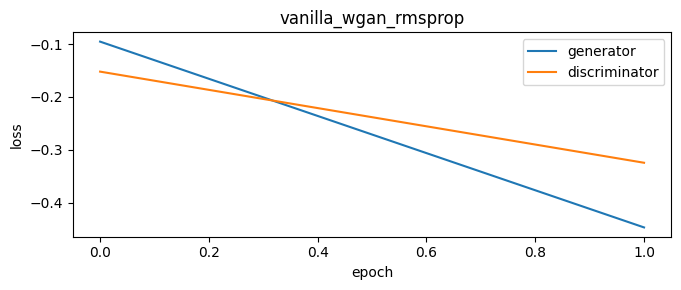

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,-0.32456
epoch,2
g_loss,-0.44687



starting: dcgan_bce_adam


  epoch 1/2  g_loss=1.0648  d_loss=0.5787
  epoch 2/2  g_loss=0.9471  d_loss=0.5993


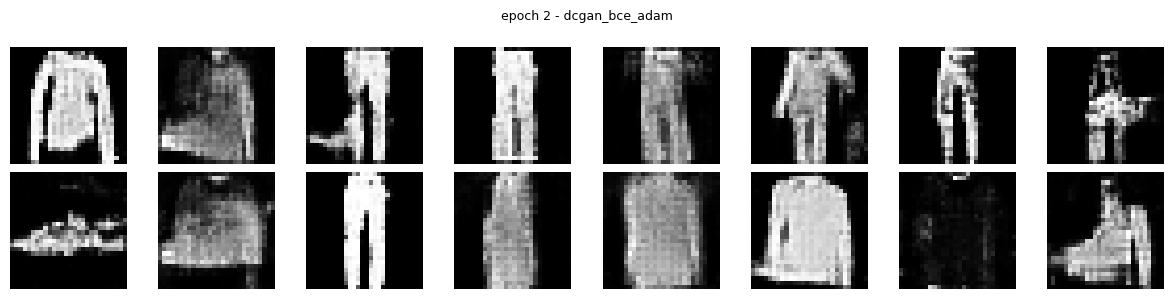

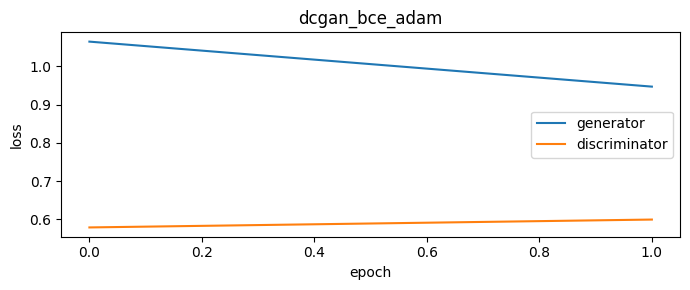

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,0.59931
epoch,2
g_loss,0.94705



starting: dcgan_bce_sgd


  epoch 1/2  g_loss=6.4171  d_loss=0.0292
  epoch 2/2  g_loss=7.8201  d_loss=0.0007


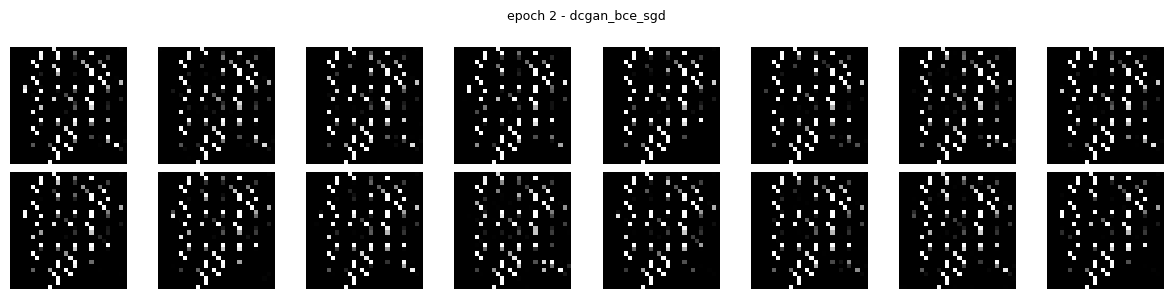

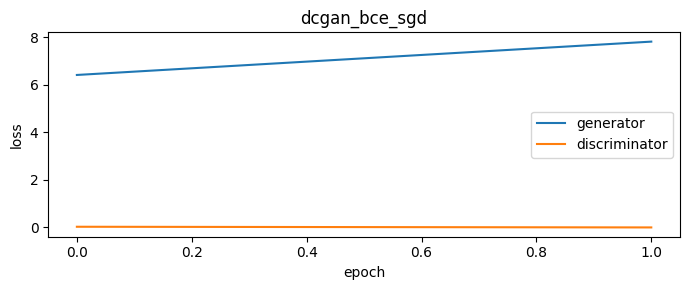

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,0.00072
epoch,2
g_loss,7.82014



starting: dcgan_bce_rmsprop


  epoch 1/2  g_loss=4.7368  d_loss=0.0426
  epoch 2/2  g_loss=1.8821  d_loss=0.4953


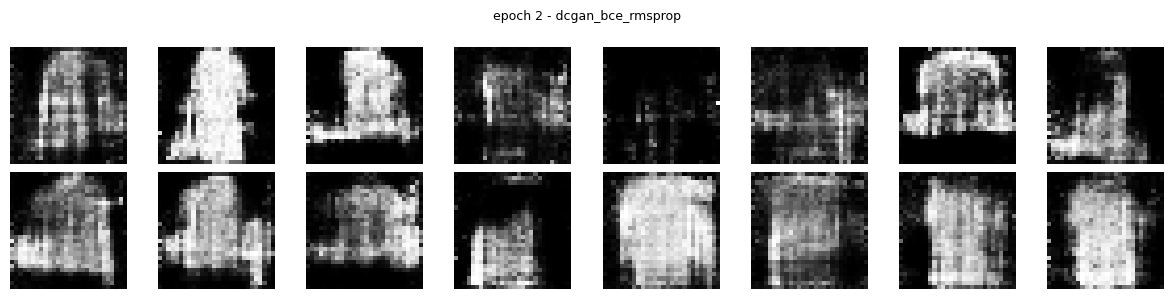

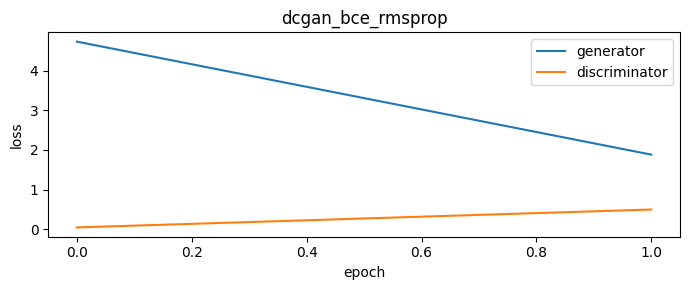

d_loss,▁█
epoch,▁█
g_loss,█▁
d_loss,0.49528
epoch,2
g_loss,1.88209



starting: dcgan_lsgan_adam


  epoch 1/2  g_loss=0.4141  d_loss=0.2876
  epoch 2/2  g_loss=0.3817  d_loss=0.2213


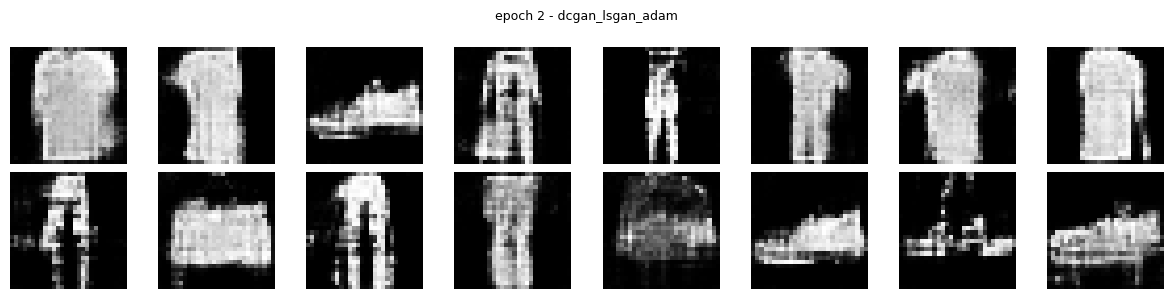

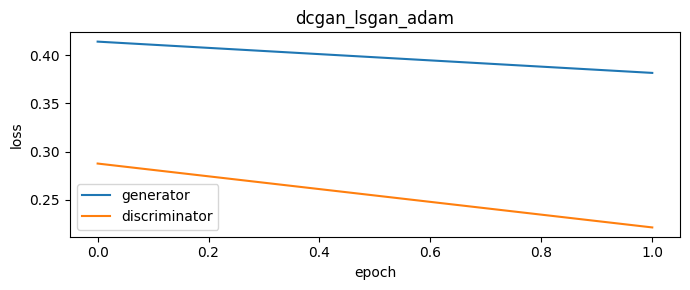

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,0.22128
epoch,2
g_loss,0.38165



starting: dcgan_lsgan_sgd


  epoch 1/2  g_loss=3.8708  d_loss=1.0944
  epoch 2/2  g_loss=1.0207  d_loss=0.0144


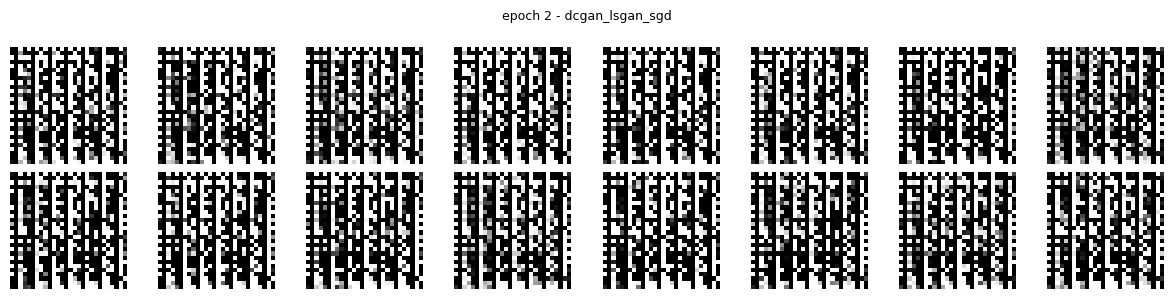

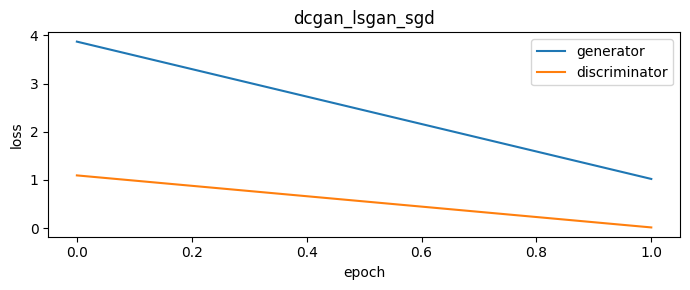

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,0.01443
epoch,2
g_loss,1.02071



starting: dcgan_lsgan_rmsprop


  epoch 1/2  g_loss=1.0221  d_loss=0.0469
  epoch 2/2  g_loss=1.0205  d_loss=0.0219


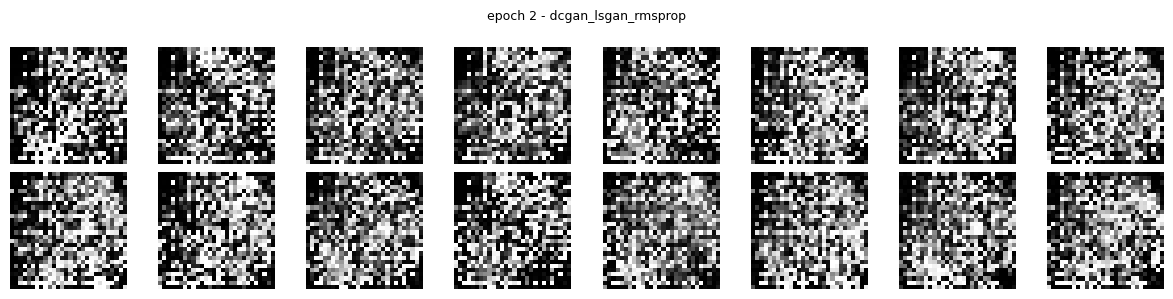

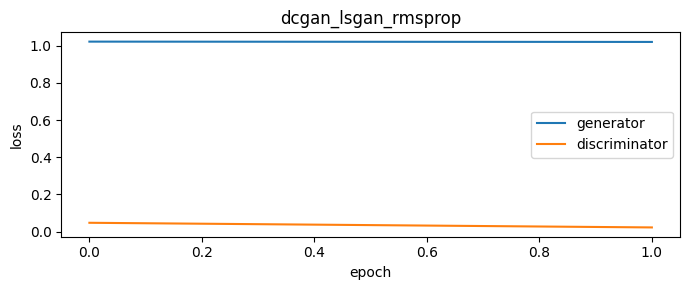

d_loss,█▁
epoch,▁█
g_loss,█▁
d_loss,0.0219
epoch,2
g_loss,1.02046



starting: dcgan_wgan_adam


  epoch 1/2  g_loss=-0.0027  d_loss=0.0015
  epoch 2/2  g_loss=-0.0015  d_loss=0.0001


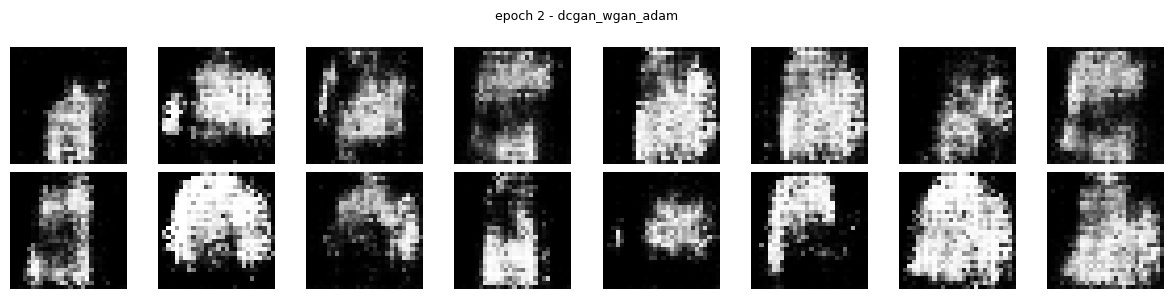

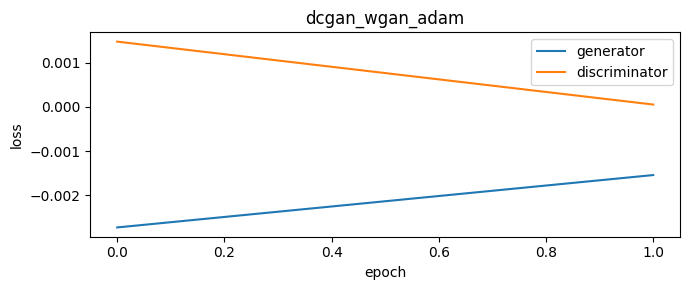

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,5e-05
epoch,2
g_loss,-0.00154



starting: dcgan_wgan_sgd


  epoch 1/2  g_loss=0.1415  d_loss=-0.3183
  epoch 2/2  g_loss=0.1419  d_loss=-0.3348


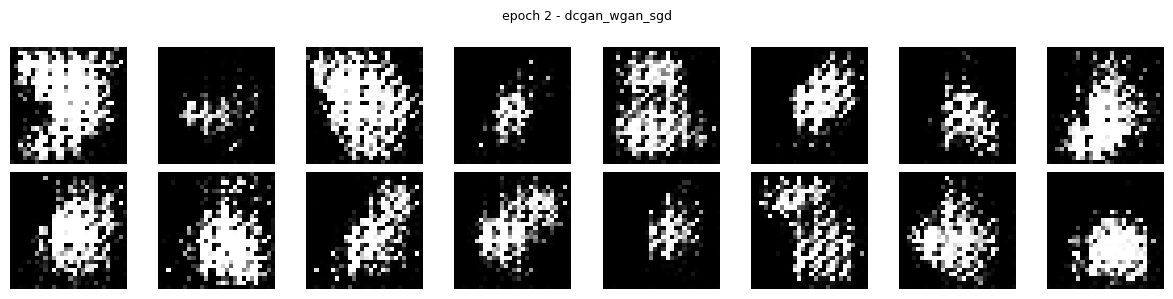

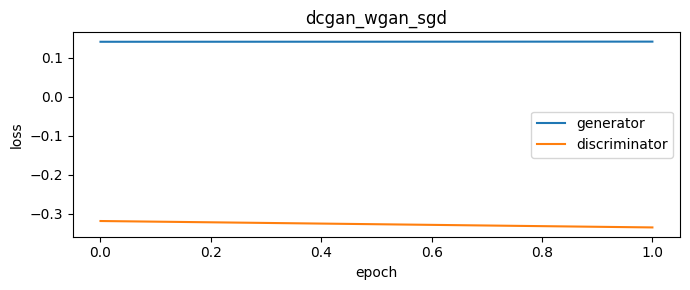

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,-0.33478
epoch,2
g_loss,0.1419



starting: dcgan_wgan_rmsprop


  epoch 1/2  g_loss=-0.0072  d_loss=0.0017
  epoch 2/2  g_loss=-0.0012  d_loss=-0.0009


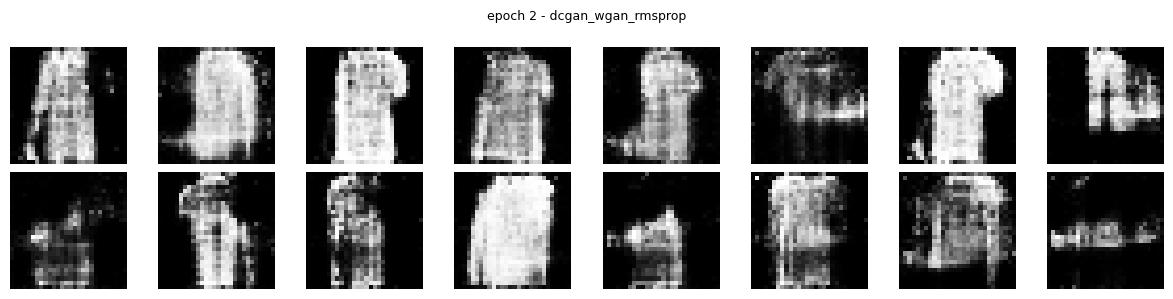

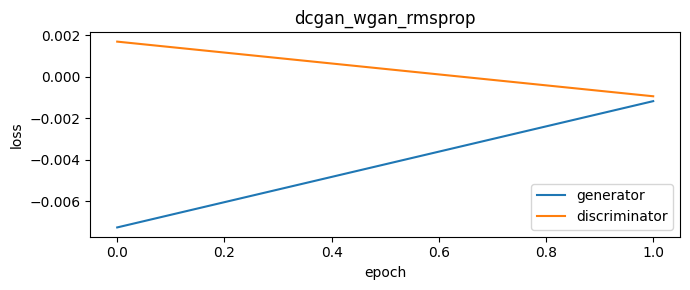

d_loss,█▁
epoch,▁█
g_loss,▁█
d_loss,-0.00094
epoch,2
g_loss,-0.00117


In [15]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [16]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_rmsprop                   -0.4469    -0.3246
vanilla_wgan_adam                      -0.2552    -0.1748
dcgan_wgan_adam                        -0.0015     0.0001
dcgan_wgan_rmsprop                     -0.0012    -0.0009
dcgan_wgan_sgd                          0.1419    -0.3348
dcgan_lsgan_adam                        0.3817     0.2213
vanilla_lsgan_adam                      0.7077     0.1500
dcgan_bce_adam                          0.9471     0.5993
vanilla_lsgan_rmsprop                   0.9653     0.0725
dcgan_lsgan_rmsprop                     1.0205     0.0219
dcgan_lsgan_sgd                         1.0207     0.0144
vanilla_lsgan_sgd                       1.0221     0.0308
vanilla_bce_rmsprop                     1.0946     0.4764
vanilla_bce_adam                        1.3106     0.5737
vanilla_bce_sgd                         1.4606     0.3279
dcgan_bce_rmsp